# 01 · Explore the LCSE dataset

Solvated ligand conformational strain energy (LCSE) for 7887 PDB ligands, computed with AIMNet2-CPCM as
`E(bound, torsion-constrained) − E(global minimum in CPCM water)`. This notebook reproduces the headline numbers and
the main distributions of the paper from `data/lcse_master_table.csv`. No model or GPU is needed.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from lcse import load_master_table
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREY = '#1f5f8b', '#c8553d', '#8a8f98'
df = load_master_table()
df.head(3).T

ligand_id,6SH_5LAR_A_401,6SL_5KGD_A_420,6SW_5KHH_A_701
pdbid,5LAR,5KGD,5KHH
ligand_code,6SH,6SL,6SW
smiles,NC(=O)[C@H](CCC1CCCCC1)NC(=O)c1ccc(CNC(=O)c2cn...,c1cncc(-c2nc3ccccc3[nH]2)c1,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@@H]2CO[P@@](=O)([...
net_charge,0,0,-1
n_heavy,37,15,22
n_rotatable,12,1,1
aromatic_proportion,0.459459,1.0,0.409091
n_aromatic_rings,3,3,2
n_aliphatic_rings,1,0,2
n_hba,6,2,10


## Headline numbers

In [2]:
print(f"ligands: {len(df)}   cofactors: {(df.ligand_function == 'cofactor').sum()}   "
      f"chemical species occurring in >1 entry: {(df.groupby('global_pair').size() > 1).sum()}")
print(f"LCSE: median {df.lcse_kcal.median():.1f}, mean {df.lcse_kcal.mean():.1f}, P75 {df.lcse_kcal.quantile(.75):.1f} kcal/mol")
hi = df[df.lcse_kcal > 25]
print(f"ligands above 25 kcal/mol: {len(hi)}, of which {(hi.net_charge <= -2).sum()} carry net charge -2 to -4 (Table S1)")
hi[['ligand_code', 'net_charge', 'n_heavy', 'lcse_kcal']].sort_values('lcse_kcal', ascending=False).head(5).round(1)

ligands: 7887   cofactors: 304   chemical species occurring in >1 entry: 691
LCSE: median 4.0, mean 5.4, P75 8.1 kcal/mol
ligands above 25 kcal/mol: 17, of which 16 carry net charge -2 to -4 (Table S1)


,ligand_code,net_charge,n_heavy,lcse_kcal
ligand_id,,,,
MHA_1IX1_B_1401,MHA,-1,13,31.4
ATP_6GU5_A_303,ATP,-4,31,29.5
ATP_4MB2_B_301,ATP,-4,31,29.2
8DP_5MLD_G_301,8DP,-2,31,28.4
ATP_2YXU_B_2410,ATP,-4,31,28.3


## Distribution and dependence on net charge

Strain rises with |net charge| and does so asymmetrically. Values at −3 and −4 are upper bounds (continuum solvation over-stabilizes compact polyanion conformers).

,size,median,P75
net_charge,,,
-6,7,13.6,13.9
-5,9,7.6,9.4
-4,194,17.7,21.5
-3,590,12.2,14.0
-2,1070,9.1,11.6
-1,1292,2.6,6.0
0,3188,2.7,5.1
1,1299,3.4,6.2
2,165,6.3,8.4


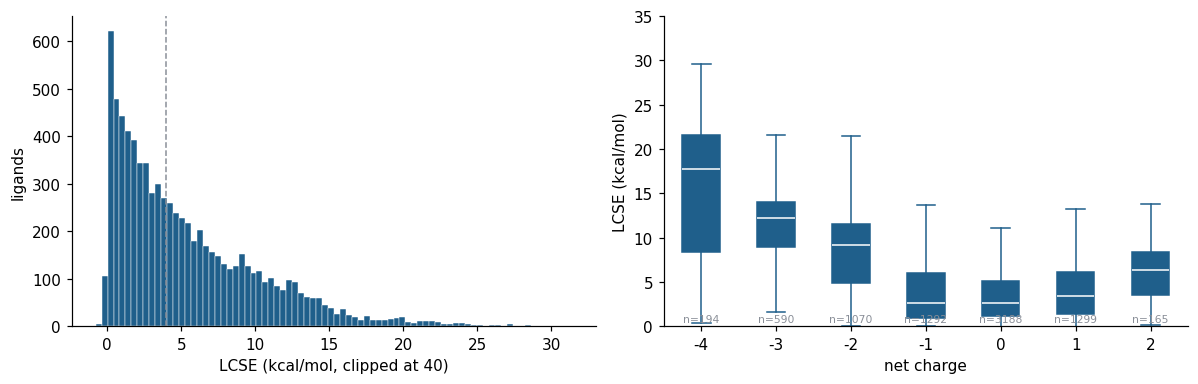

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(df.lcse_kcal.clip(upper=40), bins=80, color=BLUE, edgecolor='white', lw=.3)
ax[0].axvline(df.lcse_kcal.median(), color=GREY, ls='--', lw=1); ax[0].set_xlabel('LCSE (kcal/mol, clipped at 40)'); ax[0].set_ylabel('ligands')
order = [-4, -3, -2, -1, 0, 1, 2]
data = [df[df.net_charge == q].lcse_kcal.values for q in order]
ax[1].boxplot(data, tick_labels=[str(q) for q in order], showfliers=False, patch_artist=True,
              boxprops=dict(facecolor=BLUE, edgecolor=BLUE), medianprops=dict(color='white'), whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE))
for i, q in enumerate(order): ax[1].text(i + 1, 0.5, f"n={len(data[i])}", ha='center', fontsize=7, color=GREY)
ax[1].set_xlabel('net charge'); ax[1].set_ylabel('LCSE (kcal/mol)'); ax[1].set_ylim(0, 35)
plt.tight_layout()
df.groupby('net_charge').lcse_kcal.agg(['size', 'median', lambda s: s.quantile(.75)]).rename(columns={'<lambda_0>': 'P75'}).round(1)

## Size, flexibility, aromaticity

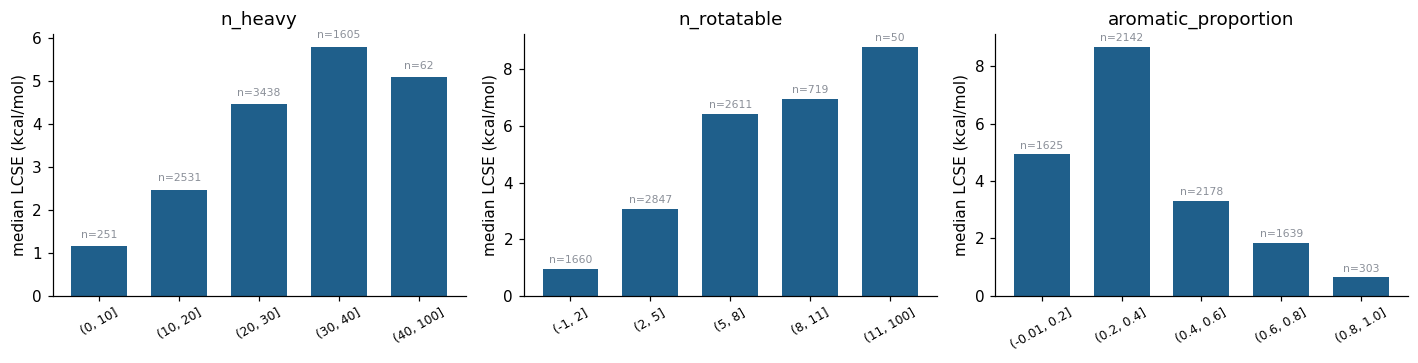

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
bins = {'n_heavy': [0, 10, 20, 30, 40, 100], 'n_rotatable': [-1, 2, 5, 8, 11, 100], 'aromatic_proportion': [-0.01, .2, .4, .6, .8, 1.0]}
for a, (col, b) in zip(ax, bins.items()):
    g = pd.cut(df[col], b); med = df.groupby(g, observed=True).lcse_kcal.median(); n = df.groupby(g, observed=True).size()
    a.bar(range(len(med)), med.values, color=BLUE, width=.7); a.set_xticks(range(len(med))); a.set_xticklabels([str(i) for i in med.index], rotation=30, fontsize=8)
    for i, (m, k) in enumerate(zip(med.values, n.values)): a.text(i, m + .2, f"n={k}", ha='center', fontsize=7, color=GREY)
    a.set_title(col); a.set_ylabel('median LCSE (kcal/mol)')
plt.tight_layout()

## Enzyme classes (non-cofactor ligands)

Classes with elevated strain (ligases, lyases, isomerases) disproportionately bind charged nucleotide-phosphate ligands; the pattern reflects chemotype, not enzyme class.

In [5]:
ec = df[df.ligand_function.isna() & df.enzyme_class.notna()]
t = ec.groupby('enzyme_class').lcse_kcal.agg(['size', 'median', 'mean', lambda s: s.quantile(.75)]).rename(columns={'<lambda_0>': 'P75'})
t['frac_charge_le_-2'] = ec.groupby('enzyme_class').apply(lambda g: (g.net_charge <= -2).mean(), include_groups=False)
t[t['size'] >= 20].sort_values('median').round(2)

,size,median,mean,P75,frac_charge_le_-2
enzyme_class,,,,,
Oxidoreductases,741,3.19,4.30,6.75,0.18
Transferases,2487,3.42,5.02,7.21,0.21
Hydrolases,1332,3.84,4.88,6.79,0.12
Isomerases,183,6.31,6.91,10.69,0.46
Lyases,277,7.45,7.69,11.08,0.57
Ligases,213,7.87,7.99,11.19,0.37


## The same ligand across targets

A ligand's strain is a property of the bound pose. FMN is bimodal across its 186 entries.

48 ligand codes with >=10 entries; median within-ligand range 7.5 kcal/mol; 33% span more than 10 kcal/mol


,size,min,median,max,range
ligand_code,,,,,
ATP,54,8.4,21.3,29.5,21.1
ZMR,14,0.6,3.0,19.7,19.1
ADP,158,1.6,12.8,19.8,18.2
GDP,119,0.9,12.9,18.8,17.8
FMN,186,0.3,5.3,16.2,15.9
G6P,12,1.5,10.5,17.4,15.9
ANP,18,7.9,19.4,22.8,14.9
SAL,10,0.0,0.1,13.5,13.5
AMP,156,2.7,9.5,15.6,12.9


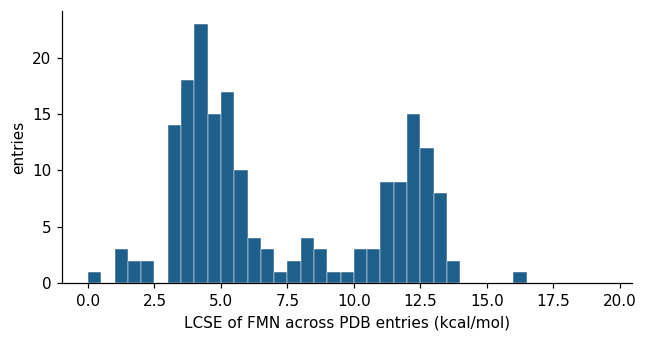

In [6]:
multi = df.groupby('ligand_code').filter(lambda g: len(g) >= 10)
rng = multi.groupby('ligand_code').lcse_kcal.agg(['size', 'min', 'median', 'max'])
rng['range'] = rng['max'] - rng['min']
print(f"{len(rng)} ligand codes with >=10 entries; median within-ligand range {rng['range'].median():.1f} kcal/mol; "
      f"{(rng['range'] > 10).mean():.0%} span more than 10 kcal/mol")
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(df[df.ligand_code == 'FMN'].lcse_kcal, bins=np.arange(0, 20, .5), color=BLUE, edgecolor='white', lw=.3)
ax.set_xlabel('LCSE of FMN across PDB entries (kcal/mol)'); ax.set_ylabel('entries'); plt.tight_layout()
rng.sort_values('range', ascending=False).head(10).round(1)

## Force fields

MMFF94 reproduces neutral strain and overstates charged strain; re-optimizing both endpoints on MMFF94 widens the gap (Figure S15). A solvated force field (GAFF2/OBC2, `data/gaff2_obc2_subset.csv`) removes most of it (Figure S16).

In [7]:
d = df.dropna(subset=['mmff94_strain_sp_kcal'])
d = d.assign(qcls=d.net_charge.clip(-3, 2), diff_sp=d.mmff94_strain_sp_kcal - d.lcse_kcal, diff_reopt=d.mmff94_strain_reopt_kcal - d.lcse_kcal)
d.groupby('qcls')[['diff_sp', 'diff_reopt']].agg(['median', lambda s: s.abs().median()]).round(1)

diff_sp            diff_reopt           
      median <lambda_0>     median <lambda_0>
qcls                                         
-3      20.3       20.6       29.2       29.2
-2      11.6       12.4       19.6       19.7
-1       0.4        2.9        3.1        3.9
 0       0.0        2.2        1.3        2.6
 1       0.7        3.5        3.3        4.1
 2      -1.1        8.4        4.2        6.3